# **16장. 트랜스포머를 활용한 문장 생성 모델**

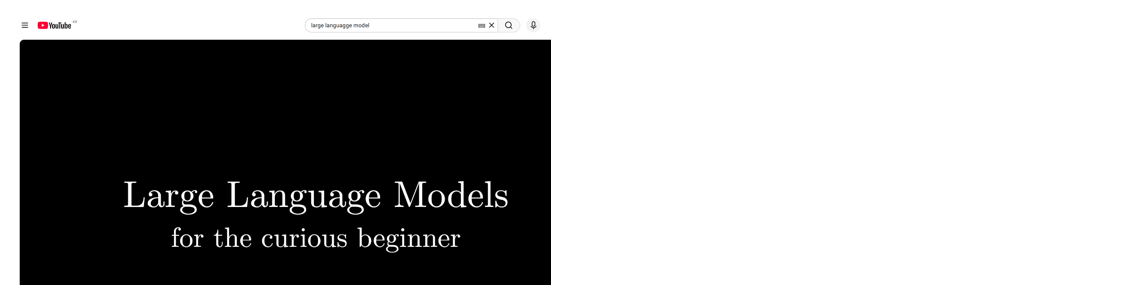

https://www.youtube.com/watch?v=LPZh9BOjkQs


이 동영상은 트랜스포머 모델을 사용하는 **대규모 언어모델**(LLM)의 구조를 잘 설명하고 있습니다.  


---



In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import numpy as np; import matplotlib.pyplot as plt
import tensorflow as tf; import random; import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 76.6 MB/s eta 0:00:00


[실습 16-01]

In [ ]:
# 저자의 github에서 미리 만들어둔 트랜스포머 클래스 불러오기
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
from mini_transformers import TextEmbedding, TransformerBlock

--2026-08-02 21:45:09--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_transformers.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7391 (7.2K) [text/plain]
Saving to: ‘mini_transformers.py’

mini_transformers.p 100%[===================>]   7.22K  --.-KB/s    in 0s      

2026-08-02 21:45:09 (110 MB/s) - ‘mini_transformers.py’ saved [7391/7391]



[실습 16-02]

In [ ]:
# 말뭉치 로드 및 전처리
with open('메밀꽃.txt', 'r', encoding='cp949') as f:
        text = f.read().lower()

# 불필요한 공백 및 특수문자 정제
text = re.sub(r'\s+', ' ', text)
text = re.sub(r"([?.!,])", r" \1 ", text)
text

'여름 장이란 애당초에 글러서 ,  해는 아직 중천에 있건만 장판은 벌써 쓸쓸하고 더운 햇발이 벌여 놓은 전 휘장 밑으로 등줄기를 훅훅 볶는다 .  마을 사람들은 거지반 돌아간 뒤요 ,  팔리지 못한 나무꾼 패가 길거리에 궁싯거리고들 있으나 ,  석유병이나 받고 고깃마리나 사면 족할 이 축들을 바라고 언제까지든지 버티고 있을 법은 없다 .  춥춥스럽게 날아드는 파리 떼도 장난꾼 각다귀들도 귀찮다 .  얼금뱅이요 왼손잡이인 드팀전의 허 생원은 기어코 동업의 조 선달을 나꾸어 보았다 .  “그만 거둘까 ? ” “잘 생각했네 .  봉평장에서 한 번이나 흐붓하게 사 본 일 있었을까 .  내일 대화장에서나 한몫 벌어야겠네 . ” “오늘 밤은 밤을 새서 걸어야 될걸 ? ” “달이 뜨렷다 ? ” 절렁절렁 소리를 내며 조 선달이 그 날 산 돈을 따지는 것을 보고 허 생원은 말뚝에서 넓은 휘장을 걷고 벌여 놓았던 물건을 거두기 시작하였다 .  무명 필과 주단바리가 두 고리짝에 꽉 찼다 .  멍석 위에는 천 조각이 어수선하게 남았다 .  다른 축들도 벌써 거진 전들을 걷고 있었다 .  약빠르게 떠나는 패도 있었다 .  어물 장수도 ,  땜장이도 ,  엿 장수도 ,  생강 장수도 꼴들이 보이지 않았다 .  내일은 진부와 대화에 장이 선다 .  축들은 그 어느 쪽으로든지 밤을 새워 육칠십리 밤길을 타박거리지 않으면 안 된다 .  장판은 잔치 뒤 마당같이 어수선하게 벌어지고 ,  술집에서는 싸움이 터져 있었다 .  주정꾼 욕지거리에 섞여 계집의 앙칼진 목소리가 찢어졌다 .  장날 저녁은 정해 놓고 계집의 고함소리로 시작되는 것이다 .  “생원 ,  시침을 떼두 다 아네…… .  충줏집 말이야 . ” 계집 목소리로 문득 생각난 듯이 조 선달은 비죽이 웃는다 .  “화중지병이지 연소패들을 적수로 하구야 대거리가 돼야 말이지 . ” “그렇지두 않을걸 .  축들이 사족을 못 쓰는 것두 사실은 사실이나 ,  아무리 그렇다군 해두 왜 그 동이 말일세 .  감쪽같이 충줏집을 후린 눈치거든 . ”

[실습 16-03]

In [ ]:
# 토큰화
tokenizer = Tokenizer(filters='')
tokenizer.fit_on_texts([text])
tokens = tokenizer.texts_to_sequences([text])[0]
print(tokens[:20]); print()

# 토큰--> 인덱스 딕셔너리
print("인코딩 사전")
print(tokenizer.word_index); print()
# 인덱스 --> 인덱스 딕셔너리
index_word={v: k for k, v in tokenizer.word_index.items()}
print("디코딩 사전")
print(index_word); print()

vocab_size = len(tokenizer.word_index) + 1  # 0은 특수 목적 토큰
print(f"고유 토큰의 수: {vocab_size}")

[249, 250, 251, 252, 3, 253, 254, 255, 256, 44, 10, 84, 85, 257, 86, 87, 258, 259, 260, 261]

인코딩 사전
{'.': 1, '”': 2, ',': 3, '허': 4, '?': 5, '생원은': 6, '수': 7, '그': 8, '조': 9, '벌써': 10, '한': 11, '안': 12, '하고': 13, '있었다': 14, '다': 15, '듯이': 16, '없었다': 17, '동이의': 18, '것을': 19, '때에는': 20, '하나': 21, '같은': 22, '있는': 23, '이': 24, '소리를': 25, '걷고': 26, '않았다': 27, '계집': 28, '선달은': 29, '동이': 30, '하여도': 31, '때': 32, '없이': 33, '젊은': 34, '것이었다': 35, '것': 36, '몇': 37, '되었다': 38, '없어': 39, '동이는': 40, '시작한': 41, '까닭에': 42, '것이': 43, '장판은': 44, '기어코': 45, '번이나': 46, '본': 47, '선달이': 48, '날': 49, '보고': 50, '장수도': 51, '않으면': 52, '된다': 53, '것이다': 54, '말이야': 55, '충줏집을': 56, '알': 57, '내': 58, '않는': 59, '버렸다': 60, '제법': 61, '녀석이': 62, '꼴에': 63, '하였으나': 64, '그러나': 65, '때문에': 66, '지난': 67, '같이': 68, '달빛에': 69, '장에서': 70, '장으로': 71, '젖은': 72, '더': 73, '않은': 74, '저': 75, '꼴이': 76, '좀': 77, '가슴이': 78, '해서': 79, '지금': 80, '사람은': 81, '없어요': 82, '나귀': 83, '쓸쓸하고': 84, '더운': 85, '벌여': 86, '놓은': 87, '거지반': 88, '뒤요': 89,

[실습 16-04]

In [ ]:
seq_length=50  # 시퀀스의 길이

X_seq, y_seq = [], []

for i in range(len(tokens)-seq_length):
    X_seq.append(tokens[i:i+seq_length])
    y_seq.append(tokens[i+1:i+seq_length+1])
X = np.array(X_seq); y = np.array(y_seq)

print(f"입력(X): 차원= {X.shape}")
print(X); print()
print(f"타깃(y): 차원= {y.shape}")
print(y)

입력(X): 차원= (2346, 50)
[[ 249  250  251 ...   90  283   91]
 [ 250  251  252 ...  283   91    1]
 [ 251  252    3 ...   91    1  284]
 ...
 [   1    2 1581 ...  149    1  222]
 [   2 1581 1582 ...    1  222  245]
 [1581 1582    5 ...  222  245 1602]]

타깃(y): 차원= (2346, 50)
[[ 250  251  252 ...  283   91    1]
 [ 251  252    3 ...   91    1  284]
 [ 252    3  253 ...    1  284  285]
 ...
 [   2 1581 1582 ...    1  222  245]
 [1581 1582    5 ...  222  245 1602]
 [1582    5    2 ...  245 1602    1]]


[실습 16-05]

In [ ]:
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 임베딩 차원 설정
embed_dim=32

# 모델 설정
model=Sequential([
    Input(shape=(seq_length,)),
    TextEmbedding(input_dim=vocab_size, output_dim=embed_dim),   # 임베딩+포지션_인코딩
    TransformerBlock(num_heads=4, return_sequences=True, use_causal_mask=True),
    TransformerBlock(num_heads=4, return_sequences=True, use_causal_mask=True),
    Dropout(0.5),
    Dense(vocab_size, activation='softmax')
    ])

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

# 모델 학습 (에포크 수 조절)
history = model.fit(X, y, epochs=10)


Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.1326 - loss: 6.0303
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4275 - loss: 3.0570
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5818 - loss: 1.8903
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6253 - loss: 1.5557
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6473 - loss: 1.3659
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6709 - loss: 1.2036
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6922 - loss: 1.0750
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7130 - loss: 0.9781
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7331 - loss: 0.8962
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7486 - loss: 0.8393


손실변화 시각화

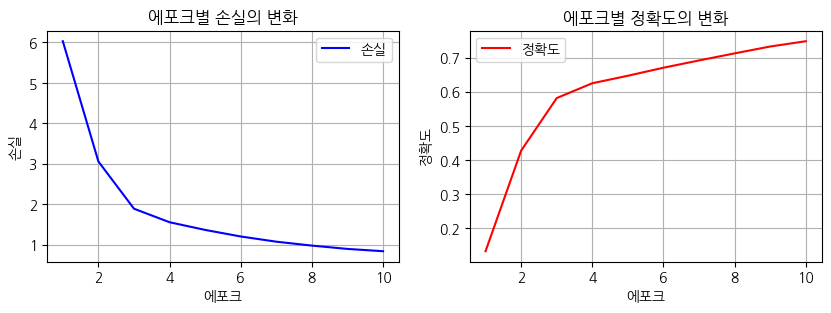

In [ ]:
epochs=range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(10, 3))

plt.subplot(1,2,1)
plt.plot(epochs, history.history['loss'], 'b-', label="손실")
plt.title('에포크별 손실의 변화')
plt.xlabel('에포크'); plt.ylabel('손실')
plt.grid(); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history.history['accuracy'], 'r-', label="정확도")

plt.title('에포크별 정확도의 변화')
plt.xlabel('에포크'); plt.ylabel('정확도')
plt.grid(); plt.legend(); plt.show()


# Temperature 샘플링

In [ ]:
def generate(seed_text, length, temperature=1.0):
    generated_tokens = []

    for _ in range(length):
        # 1. 시드 텍스트 토큰화 및 시퀀스 길이 맞추기
        curr_tokens = tokenizer.texts_to_sequences([seed_text])[0]
        if len(curr_tokens) > seq_length:
            curr_tokens = curr_tokens[-seq_length:]
        pad_tokens = pad_sequences([curr_tokens], maxlen=seq_length, padding='pre')

        # 2. 모델에 입력하여 확률 예측
        probs_all = model.predict(pad_tokens, verbose=0)  # 모든 타임 스텝
        probs = probs_all[0, -1, :]                       # 마지막 타임 스텝의 확률만 추출

        # 3. 반복 패널티 적용 (최근 생성된 20개 토큰의 확률을 2배 축소)
        # 팁: 나눗셈 비율(1.5~2.0)을 직접 조절하여 페널티 강도를 조절할 수 있습니다.
        for token in set(generated_tokens[-20:]):
            probs[token] /= 2

        # 4. Temperature를 적용하여 확률 분포의 뾰족함을 조절
        p_temp = np.log(probs + 1e-10) / temperature
        next_probs = np.exp(p_temp)
        next_probs = next_probs / np.sum(next_probs)

        # 5. 샘플링 및 시드 텍스트 업데이트
        next_index = np.random.choice(len(next_probs), p=next_probs)
        generated_tokens.append(next_index)
        word = index_word.get(next_index)

        # 특수 토큰이나 존재하지 않는 단어를 만나면 종료
        if not word or word == '<pad>':
            break

        seed_text = seed_text + " " + word  # 시드 업데이트

    return seed_text

### 문장 생성

[실습 16-06]

In [ ]:
import textwrap
SEED= "해는 아직 중천에 있건만"
output = generate(seed_text=SEED, length=200, temperature=1.2)
print(textwrap.fill(output, width=60))  # 출력 넓이 조절

해는 아직 중천에 있건만 장판은 소문에 발끈 뒤집혀 고작해야 술집에 팔려가기가 상수라고 처녀의 꼴은 꿩궈
먹은 자리야 . 시침을 떼두 다 지껄였다 ― 더구나 그것이 약이 된다나 하고 하여 사흘 동안에 다 무어야 .
몽당비처럼 뼈를 찔렀다 . 그때부터 봉평이 마음에 든 것이 반평생을 두고 다니게 되었네 . 평생인들 잊을 수
있겠나 . ” “수 좋았지 . 그렇게 신통한 일이란 쉽지 않어 . 항용 못난 것 얻어 새끼 낳고 , 걱정
있을 때는 누그러지기도 쉬운 듯해서 이럭저럭 이야기가 되었네…… 생각하면 무섭고도 기막힌 밤이었어 . 그러나
늘그막바지까지 장돌뱅이로 지내기도 힘드는 노릇 아닌가 ? ” 절렁절렁 소리를 내며 조 선달은 재빨리 거의 다
들이켰다 . 동이 말일세 . 춥춥스럽게 날아드는 파리 떼도 장난꾼 각다귀들도 귀찮다 . 짐승을 데리고 읍내를
도망해 나왔을 때에는 도리어 측은히 여겨졌다 . 아직도 서름서름한 사인데 너무 과하지 않았을까 하고 하여
사흘 동안에 다 건넜을 때에는 마시던 잔을 그 자리에 소스라쳐 버린다 . ” “각다귀들 장난이지 필연코 .
좋은 데만 있으면 시집도 보내련만 시집은 죽어도 싫다지…… 그러나 처녀란 울 때같이 정을 끄는 때가 있을까
? 어머니는 집을 쫓겨났죠 . ” 짐승도 짐승이려니와 동이의 마음씨가 가슴을 울렸다 . ” “의부와도 갈라져
제천에 있죠 . 가을에는 봉평에 모셔 오려고 생각 말게 . ” “지금 어디 없이 의부를 얻어 가서 술장수를
시작했죠 . 피붙이라고는 어머니 생각뿐인데요


[실습 16-07]

In [ ]:
SEED= "산허리는 온통 메밀밭이어서"
output = generate(seed_text=SEED, length=200, temperature=1.5)
print(textwrap.fill(output, width=60) )

산허리는 온통 메밀밭이어서 개울가가 어디 없이 마음먹은 대로는 되풀이하고야 말았다 . 방울 소리가 시원스럽게
딸랑딸랑 메밀밭께로 흘러간다 . 술이 고주래서 의부라고 전망나니예요 . 철들어서부터 맞기 시작한 지 이십
년이나 되어도 허 생원은 주는 술잔이면 거의 되풀이하고야 말았다 . “아비 어미란 말에 가슴이 터지는 것도
같았으나 제겐 아버지가 없어요 . 충줏집은 입술을 쭝긋하고 술 처먹고 난질꾼인데 꼴사납다 . ” 하룬들 편할
날 밤이었네 . “늙은 주제에 암새를 내는 셈이야 . 생원과 선달이 얼버무려 넘겼다 . 흘러 버린 철
사이로는 피가 빼짓이 흘렀다 . 밤중은 돼서 혼자 발광이지 . 난 거꾸러질 때까지 이 길 걷고 저 달 볼테야
. ” 봉평이라는 것만은 들었죠 . 배를 좀 더 무서운 것들인걸 . ” “사람을 물에 빠치울 젠 딴은 대단한
나귀 새끼군 . ” “옛 처녀나 만나면 같이나 살까…… . ” 산길을 벗어나니 큰길로 틔어졌다 . “총각두
젊겠다 , 물론 미안해서가 아니라 달빛에 젖으면서 장에서 장으로 돌아다니게 되었다 . 한집안 일이니 딸에겐들
걱정이 없을 리 처녀나 만나면 같이나 살까…… . ” “웬걸요 , 아무리 그렇다군 해두 진저리나지…… .
대화쯤에 조그만 전방이나 하나 건너고 벌판과 산길을 걸어야 될걸 ? ” “달이 뜨렷다 ? ” “오늘 밤은
밤을 새서 걸어야 된다 . 동이 같은 달의 숨소리가 손에 잡힐 듯이 조 선달이 그 이야기를 끄집어내려는
것이다 . 담도 생긴 데다가 웬일인지




---



## **[더 알아보기] 트랜스포머로 음악도 작곡할 수 있을까?**
음악 역시 다양한 음표들이 시간 순으로 나열된 **시퀀스** 데이터입니다.

그렇다면 트랜스포머 모델을 악보 데이터에도 적용 가능할까요?

**YES!!** 음표와 쉼표를 고유한 **토큰으로 바꾸기만 하면** 문장 생성 모델과 동일한 구조로 기존 악보 스타일을 닮은 신곡을 만들어낼 수 있습니다.  

**절차:**


(1) **토큰화**: 미디파일(디지털 악보)의 각 음표를 음높이(pitch)와 재생 시간의 조합으로 정의합니다.
> 예를 들어 4 옥타브 솔(G4) 음이 0.5초동안 연주된다면, "G4_0.5"와 같은 문자 토큰으로 변환합니다.

> 쉼표도 R_0.25 처럼 만들 수 있습니다.    

(2) **인코딩**: 임베딩 층과 포지셔널 인코딩 층을 거쳐 각 미디 토큰을 숫자 벡터로 표현합니다.

(3) **학습**: 트랜스포머 모델에게 일정 길이의 음표 시퀀스를 보여주고, 다음 음표 토큰을 맞추도록 학습시킵니다.

(4) **생성**: 모델이 예측한 확률분포에서 음표를 반복 샘플링하여 이어붙이면 새로운 악보가 생성됩니다.  

(5) **재생**: 악보를 미디파일로 다시 변환해서 재생합니다.



이러한 모델을 **Music Transformer**라고 부를 수 있습니다.
이처럼 트랜스포머는 **범용 시퀀스 모델**입니다.



---



실습을 위해 먼저 미디 파일을 하나 불러옵시다.
* **sample.mid**는 《바흐 미뉴에트 G장조》의 메인 테마 중 일부입니다.
* 미디 파일은 디지털 악보를 말합니다.
* 인터넷에서 다양한 미디 파일을 다운로드할 수 있습니다(저작권 주의!)

샘플 파일을 세션 저장소로 업로드하고 다음 코드를 실행하면, 미디 파일을 오디오 파일로 바꾸어 곡이 재생됩니다.
* 코드의 자세한 설명은 생략합니다.

In [ ]:
!pip install pretty_midi   # 필요한 라이브러리 인스톨

In [ ]:
import pretty_midi
import numpy as np
from IPython.display import Audio

# 1. 코랩 세션에 있는 sample.mid 불러오기
pm = pretty_midi.PrettyMIDI('sample.mid')
notes = sorted(pm.instruments[0].notes, key=lambda x: x.start)

# 2. 파형 합성으로 오디오 생성
sample_rate = 22050
audio_data = []

for note in notes:
    duration = note.end - note.start
    freq = 440.0 * (2.0 ** ((note.pitch - 69) / 12.0)) # MIDI 피치 -> Hz 변환
    t = np.linspace(0, duration, int(sample_rate * duration), False)

    # 피아노 톤의 wave 생성
    wave = (0.6 * np.sin(2 * np.pi * freq * t) + 0.3 * np.sin(2 * np.pi * freq * 2 * t)) * np.exp(-3 * t)
    audio_data.extend(wave)

# 3. 오디오 재생
Audio(np.array(audio_data, dtype=np.float32), rate=sample_rate, autoplay=True)


이제 미디 파일에 있는 음표와 쉼표를 토큰으로 바꿉니다.

변환 규칙을 정해야 합니다.
* 음표는 **G4_0.50, F#_0.25**,
* 쉼표는 **R_0.25** 의 형태로 만들어봅시다.

다음 코드를 실행하면 미디파일의 음표와 쉼표가 이러한 형태의 **문자 토큰**으로 바뀝니다.
* 코드 설명은 생략합니다.


In [ ]:
# 음높이 번호 -> 음이름('G4', 'C4' 등) 변환 맵 지정
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def pitch_to_name(pitch):
    """MIDI 번호(예: 67) -> 음이름(예: 'G4') 변환"""
    return f"{NOTE_NAMES[pitch % 12]}{(pitch // 12) - 1}"

# 토큰 시퀀스 변환
melody = []
last_end_time = 0.0

for note in notes:
    # 1. 쉼표(Rest) 체크 (0.05초 이상 쉴때 추가)
    rest_duration = note.start - last_end_time
    if rest_duration >= 0.05:
        melody.append(f"R_{rest_duration:.2f}")

    # 2. 음표(Note) 변환 (예: 'G4_0.50')
    pitch_name = pitch_to_name(note.pitch)
    duration = note.end - note.start
    melody.append(f"{pitch_name}_{duration:.2f}")

    last_end_time = note.end

print(f"✅ 토큰 변환 완료! ----> 총 {len(melody)}개 토큰 추출")
print()
print("📌 변환된 미디 시퀀스")
melody

✅ 토큰 변환 완료! ----> 총 33개 토큰 추출

📌 변환된 미디 시퀀스


['G4_0.50',
 'C4_0.25',
 'D4_0.25',
 'E4_0.25',
 'F4_0.25',
 'G4_0.50',
 'C4_0.50',
 'C4_0.50',
 'R_0.25',
 'A4_0.50',
 'F4_0.25',
 'G4_0.25',
 'A4_0.25',
 'B4_0.25',
 'C5_0.50',
 'C4_0.50',
 'C4_0.50',
 'R_0.25',
 'G4_0.50',
 'C4_0.25',
 'D4_0.25',
 'E4_0.25',
 'F4_0.25',
 'G4_0.50',
 'C4_0.50',
 'C4_0.50',
 'R_0.25',
 'A4_0.50',
 'F4_0.25',
 'G4_0.25',
 'A4_0.25',
 'B4_0.25',
 'G4_1.00']

케라스 토크나이저를 사용하여 멜로디의 토큰마다 고유한 정수를 대응시켜 줍시다.

그다음 슬라이딩 윈도우 방식으로 다-대-다 구조의 입력과 타깃을 만듭니다.
* 코드는  문장생성 모델과 정확히 동일합니다.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# ==================================
# 1. Keras Tokenizer로  정수 인코딩
# ==================================
tokenizer = Tokenizer(filters='', lower=False)  # 소문자로 자동 변경 하지 않음

# 멜로디를 토크나이저로 전달
tokenizer.fit_on_texts([melody])

# 단어장 크기 계산 (패딩/0번 토큰을 고려해 +1)
vocab_size = len(tokenizer.word_index) + 1

# 문자 토큰을 정수로 변환
tokens = tokenizer.texts_to_sequences([melody])[0]

print("[정수 인코딩 완료]")
print(f"- 고유 미디 토큰의 수 : {vocab_size}")
print(f"- 토큰 사전: {list(tokenizer.word_index.items())}")
print(f"- 정수 시퀀스 출력: {tokens}\n")

# ===================================================
# 2. 슬라이딩 윈도우로 (X, y) 입력과 타깃 데이터 생성
# ===================================================

seq_length=10  # 시퀀스의 길이(이전 10개 토큰이 입력이 됨)

X_seq, y_seq = [], []

for i in range(len(tokens)-seq_length):
    X_seq.append(tokens[i:i+seq_length])
    y_seq.append(tokens[i+1:i+seq_length+1])
X = np.array(X_seq); y = np.array(y_seq)

print(f"입력(X): 차원= {X.shape}")
print(X); print()
print(f"타깃(y): 차원= {y.shape}")
print(y)

[정수 인코딩 완료]
- 고유 미디 토큰의 수 : 14
- 토큰 사전: [('C4_0.50', 1), ('G4_0.50', 2), ('F4_0.25', 3), ('R_0.25', 4), ('C4_0.25', 5), ('D4_0.25', 6), ('E4_0.25', 7), ('A4_0.50', 8), ('G4_0.25', 9), ('A4_0.25', 10), ('B4_0.25', 11), ('C5_0.50', 12), ('G4_1.00', 13)]
- 정수 시퀀스 출력: [2, 5, 6, 7, 3, 2, 1, 1, 4, 8, 3, 9, 10, 11, 12, 1, 1, 4, 2, 5, 6, 7, 3, 2, 1, 1, 4, 8, 3, 9, 10, 11, 13]

입력(X): 차원= (23, 10)
[[ 2  5  6  7  3  2  1  1  4  8]
 [ 5  6  7  3  2  1  1  4  8  3]
 [ 6  7  3  2  1  1  4  8  3  9]
 [ 7  3  2  1  1  4  8  3  9 10]
 [ 3  2  1  1  4  8  3  9 10 11]
 [ 2  1  1  4  8  3  9 10 11 12]
 [ 1  1  4  8  3  9 10 11 12  1]
 [ 1  4  8  3  9 10 11 12  1  1]
 [ 4  8  3  9 10 11 12  1  1  4]
 [ 8  3  9 10 11 12  1  1  4  2]
 [ 3  9 10 11 12  1  1  4  2  5]
 [ 9 10 11 12  1  1  4  2  5  6]
 [10 11 12  1  1  4  2  5  6  7]
 [11 12  1  1  4  2  5  6  7  3]
 [12  1  1  4  2  5  6  7  3  2]
 [ 1  1  4  2  5  6  7  3  2  1]
 [ 1  4  2  5  6  7  3  2  1  1]
 [ 4  2  5  6  7  3  2  1  1  4]
 [ 2  5  6  7 

이후 모델 설정과 학습, 샘플링 방법은  문장생성 모델과 동일합니다.

샘플링된 토큰 시퀀스를 다시 미디 파일로 바꾸어 재생할 수 있는데, 이것은 AI에게 도움을 구해보세요.  

#